In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_url = 'https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_daily_mlo.csv'
dat = pd.read_csv(data_url, comment='#', header=None)
# dat = pd.read_csv('data/co2_daily_mlo.csv', comment='#', header=None)  # if working offline, use local file
dat.columns = ['year', 'month', 'day', 'decimal_date', 'pCO2']

In [3]:
plt.style.use('presentation')

Text(0, 0.5, 'pCO2 (ppm)')

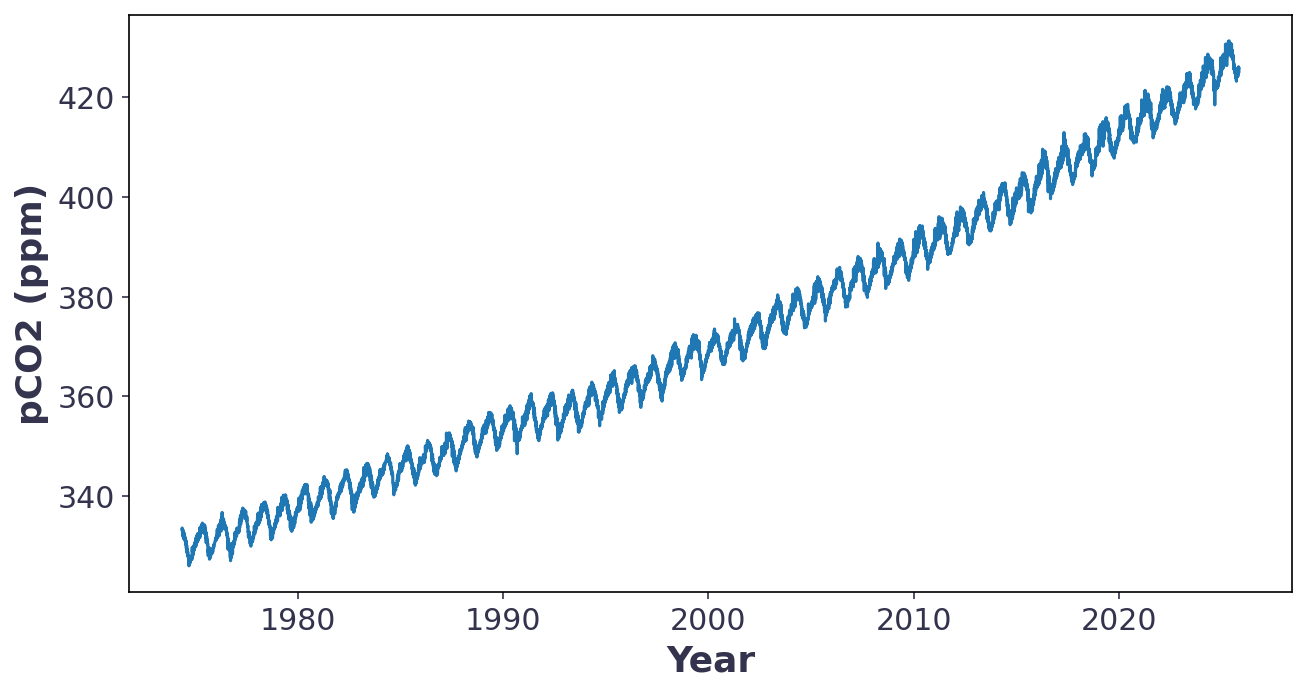

In [6]:
fig, ax = plt.subplots(1,1,figsize=(10,5))
ax.plot(dat['decimal_date'], dat['pCO2'])

ax.set_xlabel('Year')
ax.set_ylabel('pCO2 (ppm)')

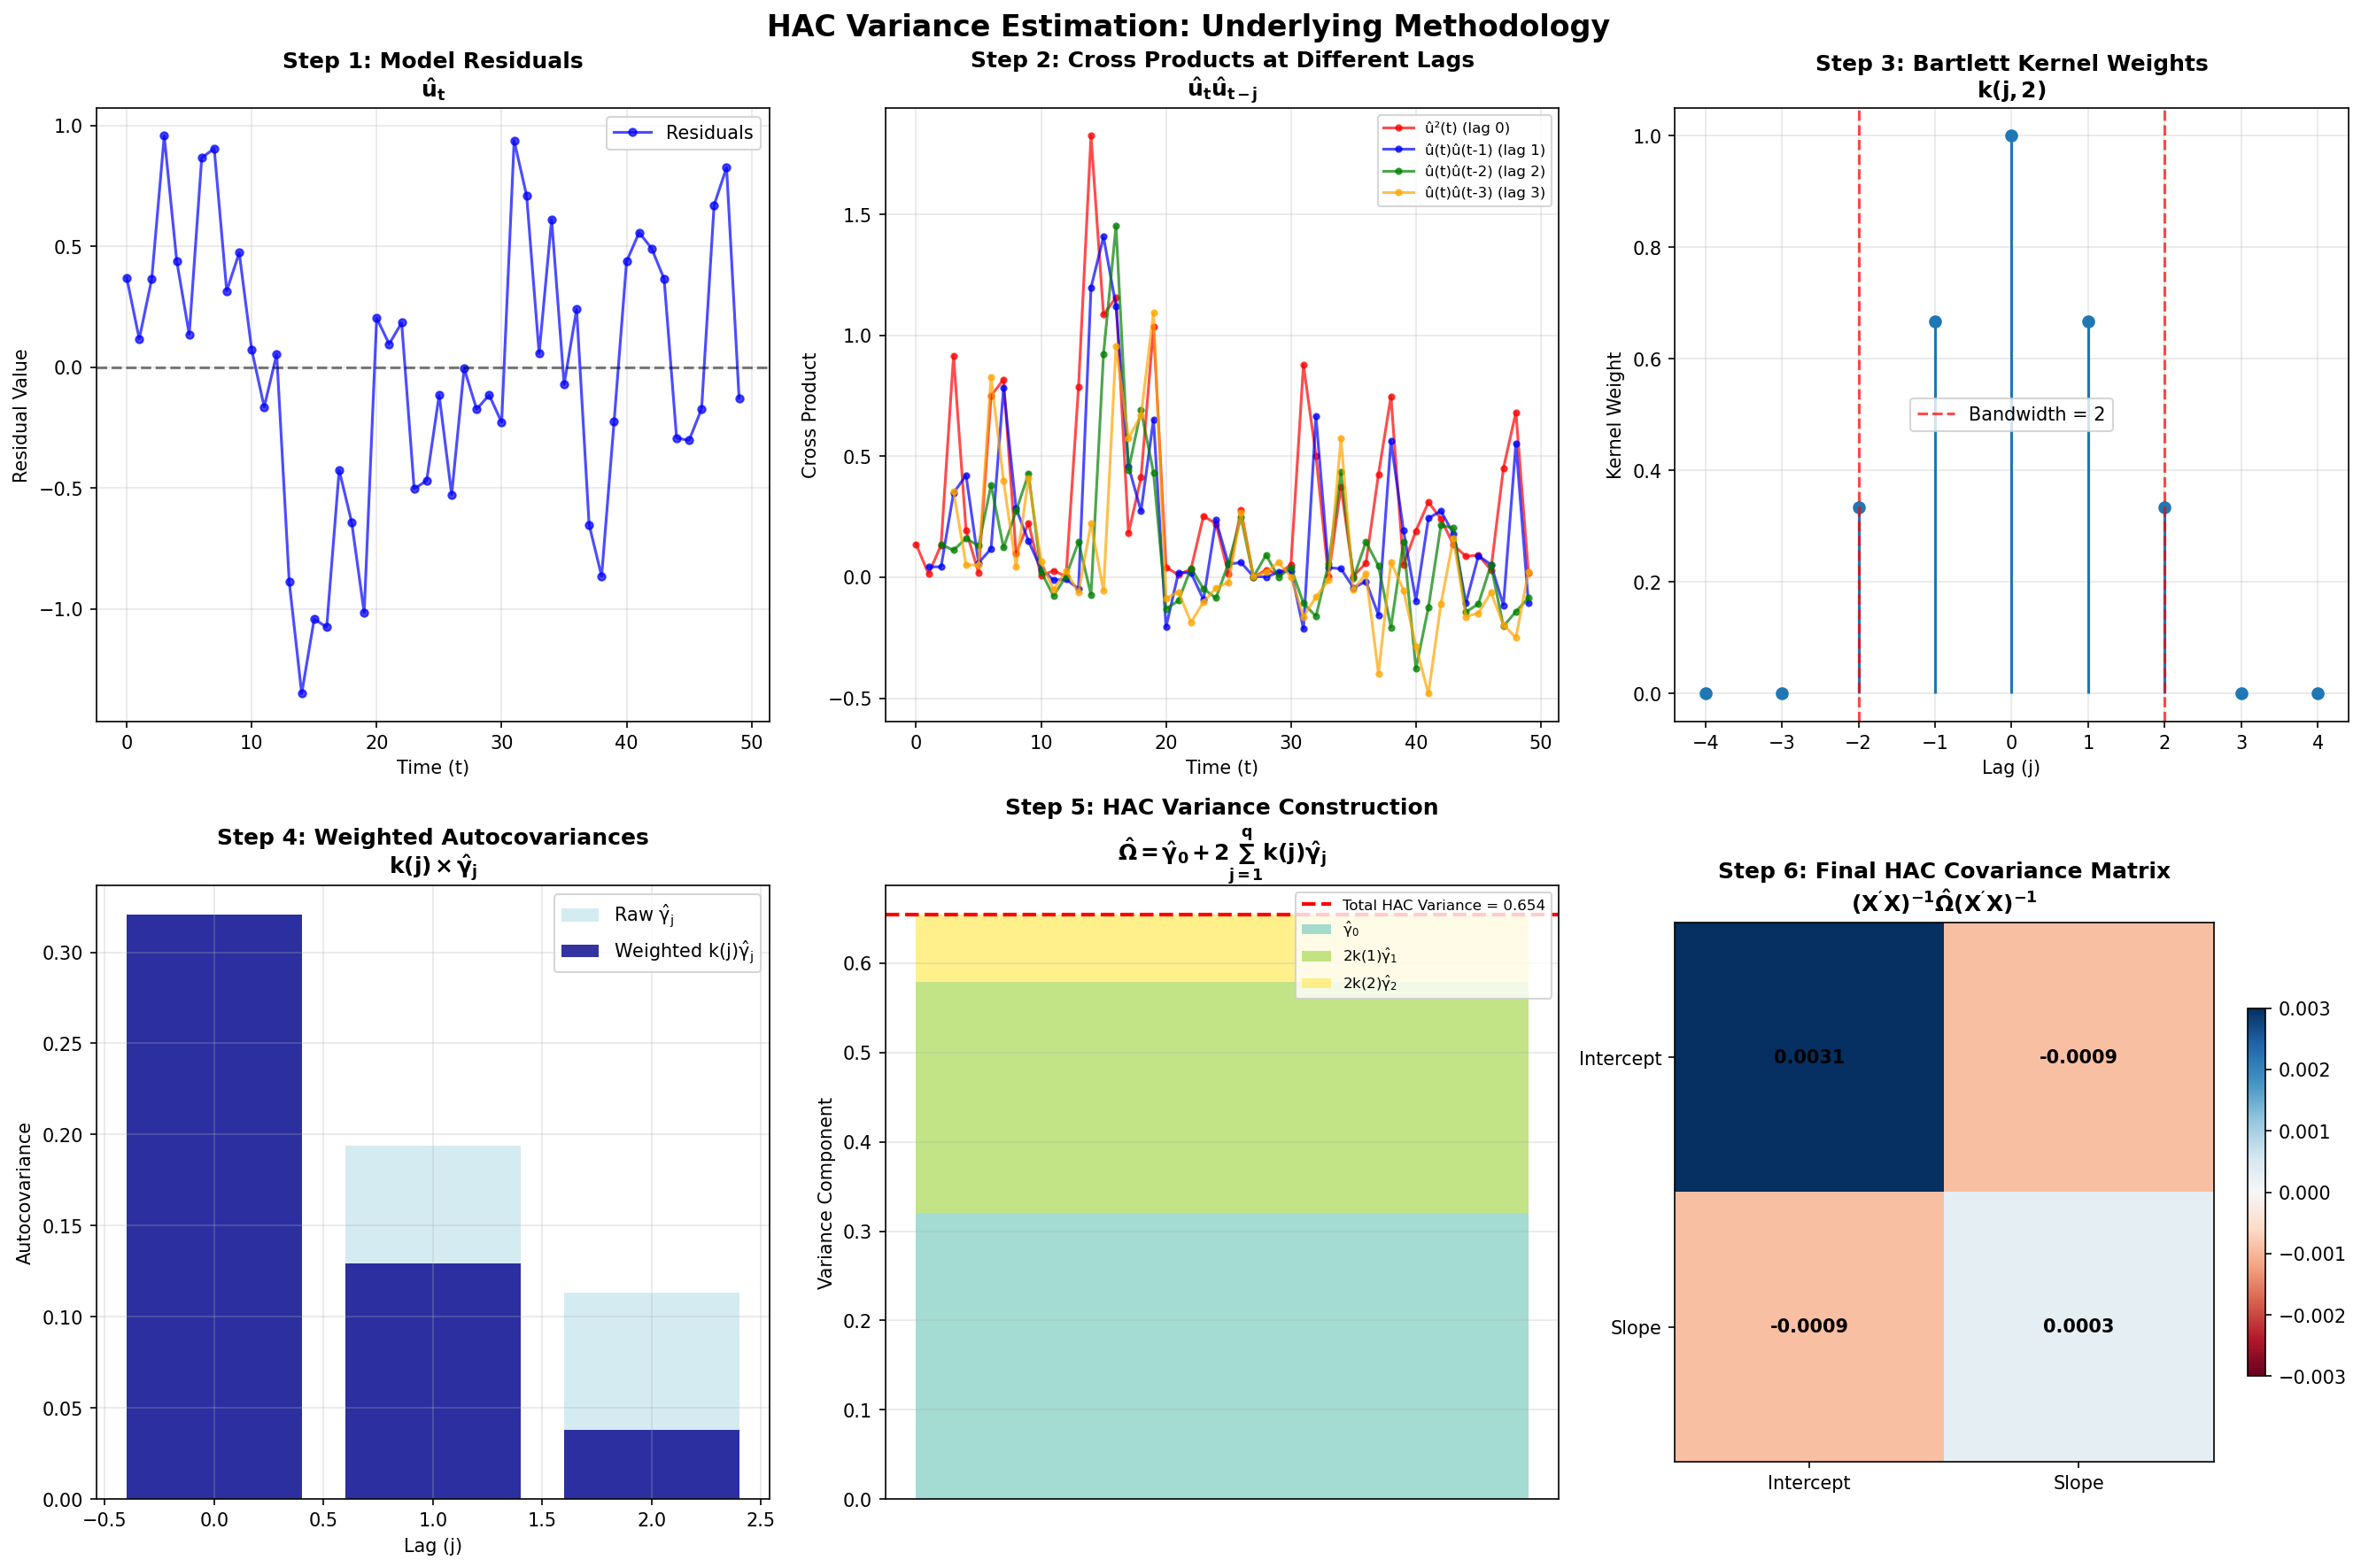

HAC Variance Estimation Formula:
1. Compute residuals: û_t = y_t - X_t'β̂
2. Calculate autocovariances: γ̂_j = (1/n) Σ û_t û_{t-j}
3. Apply kernel weights: k(j) to reduce bias
4. Construct meat matrix: Ω̂ = γ̂_0 + 2 Σ k(j)γ̂_j
5. HAC covariance: V̂_HAC = (X'X)^(-1) Ω̂ (X'X)^(-1)

Bandwidth used: 2
Number of lags included: 2


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
import pandas as pd

# Create synthetic data with autocorrelated errors
np.random.seed(42)
n = 50  # Smaller n for clearer visualization
t = np.arange(n)
x = np.linspace(0, 5, n)

# Generate autocorrelated errors
rho = 0.6
errors = np.zeros(n)
errors[0] = np.random.normal(0, 1)
for i in range(1, n):
    errors[i] = rho * errors[i-1] + np.random.normal(0, 0.5)

y = 1 + 0.5 * x + errors
df = pd.DataFrame({'y': y, 'x': x})

# Fit model and get residuals
model = ols('y ~ x', data=df).fit()
residuals = model.resid.values
X = np.column_stack([np.ones(n), x])  # Design matrix

# Calculate HAC variance matrix components
def hac_kernel(j, bandwidth):
    """Bartlett kernel for HAC estimation"""
    if abs(j) <= bandwidth:
        return 1 - abs(j) / (bandwidth + 1)
    else:
        return 0

# Choose bandwidth (rule of thumb: n^(1/4))
bandwidth = int(n**(1/4))

# Create visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('HAC Variance Estimation: Underlying Methodology', fontsize=16, fontweight='bold')

# 1. Residuals and their products
ax1 = axes[0, 0]
ax1.plot(t, residuals, 'bo-', markersize=4, alpha=0.7, label='Residuals')
ax1.axhline(0, color='k', linestyle='--', alpha=0.5)
ax1.set_title('Step 1: Model Residuals\n$\\hat{u}_t$', fontweight='bold')
ax1.set_xlabel('Time (t)')
ax1.set_ylabel('Residual Value')
ax1.grid(True, alpha=0.3)
ax1.legend()

# 2. Cross products at different lags
ax2 = axes[0, 1]
lags_to_show = [0, 1, 2, 3]
colors = ['red', 'blue', 'green', 'orange']

for i, lag in enumerate(lags_to_show):
    if lag == 0:
        cross_products = residuals**2
        label = f'û²(t) (lag {lag})'
    else:
        cross_products = residuals[lag:] * residuals[:-lag]
        label = f'û(t)û(t-{lag}) (lag {lag})'
    
    valid_t = t[lag:] if lag > 0 else t
    ax2.plot(valid_t, cross_products, 'o-', color=colors[i], 
             markersize=3, alpha=0.7, label=label)

ax2.set_title('Step 2: Cross Products at Different Lags\n$\\hat{u}_t \\hat{u}_{t-j}$', fontweight='bold')
ax2.set_xlabel('Time (t)')
ax2.set_ylabel('Cross Product')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# 3. Kernel weights
ax3 = axes[0, 2]
kernel_lags = np.arange(-bandwidth-2, bandwidth+3)
kernel_weights = [hac_kernel(j, bandwidth) for j in kernel_lags]

ax3.stem(kernel_lags, kernel_weights, basefmt=' ')
ax3.axvline(-bandwidth, color='r', linestyle='--', alpha=0.7, label=f'Bandwidth = {bandwidth}')
ax3.axvline(bandwidth, color='r', linestyle='--', alpha=0.7)
ax3.set_title(f'Step 3: Bartlett Kernel Weights\n$k(j, {bandwidth})$', fontweight='bold')
ax3.set_xlabel('Lag (j)')
ax3.set_ylabel('Kernel Weight')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Autocovariance estimation
ax4 = axes[1, 0]
max_lag = min(bandwidth, n-1)
autocovariances = []
lags = np.arange(max_lag + 1)

for j in lags:
    if j == 0:
        gamma_j = np.mean(residuals**2)
    else:
        gamma_j = np.mean(residuals[j:] * residuals[:-j])
    autocovariances.append(gamma_j)

# Apply kernel weights
weighted_autocovariances = [hac_kernel(j, bandwidth) * gamma for j, gamma in zip(lags, autocovariances)]

ax4.bar(lags, autocovariances, alpha=0.5, label='Raw $\\hat{\\gamma}_j$', color='lightblue')
ax4.bar(lags, weighted_autocovariances, alpha=0.8, label='Weighted $k(j)\\hat{\\gamma}_j$', color='darkblue')
ax4.set_title('Step 4: Weighted Autocovariances\n$k(j) \\times \\hat{\\gamma}_j$', fontweight='bold')
ax4.set_xlabel('Lag (j)')
ax4.set_ylabel('Autocovariance')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. HAC variance construction
ax5 = axes[1, 1]

# Calculate meat matrix components for illustration
meat_components = []
component_labels = []

# j = 0 term (twice because it appears once in the sum)
j0_contrib = autocovariances[0]
meat_components.append(j0_contrib)
component_labels.append('$\\hat{\\gamma}_0$')

# j > 0 terms (each appears twice due to symmetry)
for j in range(1, len(weighted_autocovariances)):
    if weighted_autocovariances[j] != 0:
        contrib = 2 * weighted_autocovariances[j]
        meat_components.append(contrib)
        component_labels.append(f'$2k({j})\\hat{{\\gamma}}_{j}$')

# Create stacked bar showing how variance is built up
cumulative = np.cumsum([0] + meat_components)
colors_stack = plt.cm.Set3(np.linspace(0, 1, len(meat_components)))

for i, (comp, label) in enumerate(zip(meat_components, component_labels)):
    ax5.bar(0, comp, bottom=cumulative[i], color=colors_stack[i], 
            alpha=0.8, label=label if i < 4 else '')

total_variance = sum(meat_components)
ax5.axhline(total_variance, color='red', linestyle='--', linewidth=2, 
           label=f'Total HAC Variance = {total_variance:.3f}')

ax5.set_title('Step 5: HAC Variance Construction\n$\\hat{\\Omega} = \\hat{\\gamma}_0 + 2\\sum_{j=1}^q k(j)\\hat{\\gamma}_j$', 
              fontweight='bold')
ax5.set_ylabel('Variance Component')
ax5.set_xticks([])
ax5.legend(fontsize=8, loc='upper right')
ax5.grid(True, alpha=0.3)

# 6. Comparison matrix visualization
ax6 = axes[1, 2]

# Simple case: just show the structure for 2x2 case (intercept + slope)
# Create simplified meat matrix
Omega_simple = np.array([[total_variance, 0.5*total_variance], 
                        [0.5*total_variance, total_variance]])

# Bread matrices (X'X)^(-1)
XtX = X.T @ X
bread = np.linalg.inv(XtX)

# HAC covariance matrix
hac_cov = bread @ Omega_simple @ bread

im = ax6.imshow(hac_cov, cmap='RdBu', vmin=-0.003, vmax=0.003)
ax6.set_title('Step 6: Final HAC Covariance Matrix\n$(X\'X)^{-1} \\hat{\\Omega} (X\'X)^{-1}$', 
              fontweight='bold')

# Add text annotations
for i in range(2):
    for j in range(2):
        text = ax6.text(j, i, f'{hac_cov[i, j]:.4f}', 
                       ha="center", va="center", color="black", fontweight='bold')

ax6.set_xticks([0, 1])
ax6.set_yticks([0, 1])
ax6.set_xticklabels(['Intercept', 'Slope'])
ax6.set_yticklabels(['Intercept', 'Slope'])

plt.colorbar(im, ax=ax6, shrink=0.6)

plt.tight_layout()
plt.show()

# Print the mathematical formula
print("HAC Variance Estimation Formula:")
print("=" * 50)
print("1. Compute residuals: û_t = y_t - X_t'β̂")
print("2. Calculate autocovariances: γ̂_j = (1/n) Σ û_t û_{t-j}")
print("3. Apply kernel weights: k(j) to reduce bias")
print("4. Construct meat matrix: Ω̂ = γ̂_0 + 2 Σ k(j)γ̂_j")
print("5. HAC covariance: V̂_HAC = (X'X)^(-1) Ω̂ (X'X)^(-1)")
print()
print(f"Bandwidth used: {bandwidth}")
print(f"Number of lags included: {max_lag}")